# Classical Baselines — ETS · Theta · MSTL · Global LightGBM

**Project phase:** Phase 4 — *Classical baselines* (see `ROADMAP.md`, "Faz 4").

> ROADMAP principle #4: *take the baseline seriously.* A complex model that cannot beat
> `SeasonalNaive` on MASE is a failure. This notebook plants the reference bar the deep-learning
> (PatchTST) and foundation-model (Chronos) tracks must clear.

Every model here is scored through the **frozen evaluation contract** defined in
`02_evaluation_framework.ipynb` and extracted into `notebooks/eval_utils.py`: the *same* 5
rolling-origin weekly windows (`data/processed/backtest_windows.parquet`), the *same* hand-rolled
metrics (MASE primary, `m=24`), the *same* `results/` layout. No metric is re-implemented here —
we only supply a `model_fn(train_wide, h)` and let the shared `run_backtest` / `evaluate` /
`update_leaderboard` do the rest.

### Models
| Model | Library | Kind | Probabilistic via |
|---|---|---|---|
| `auto_theta` | statsforecast `AutoTheta(24)` | per-series, scale-invariant | level PIs → q10..q90 |
| `auto_ets` | statsforecast `AutoETS(24)` | per-series, scale-invariant | level PIs → q10..q90 |
| `mstl` | statsforecast `MSTL([24,168])` | per-series, multi-seasonal | level PIs → q10..q90 |
| `lgbm_global` | mlforecast `LightGBM` | **global**, per-series normalized | quantile objective q10/q50/q90 |

`AutoARIMA` is intentionally **skipped** — see §5.

## 1. Setup — shared harness, data, and the bar to beat

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Import the shared evaluation harness (single source of truth for the frozen contract) ---
_here = Path.cwd()
for _base in [_here, *_here.parents]:
    if (_base / "notebooks" / "eval_utils.py").exists():
        sys.path.insert(0, str(_base / "notebooks")); break
    if (_base / "eval_utils.py").exists():
        sys.path.insert(0, str(_base)); break
import eval_utils as ev
from eval_utils import (RANDOM_SEED, HORIZON, SEASONALITY, QUANTILE_LEVELS, POINT_Q,
                        N_WINDOWS, STEP, QCOLS)

np.random.seed(RANDOM_SEED)

PROJECT_ROOT = ev.find_project_root()
paths = ev.get_paths(PROJECT_ROOT)
INTERIM, PROCESSED = paths.INTERIM, paths.PROCESSED
FORECASTS, METRICS, FIG_DIR = paths.FORECASTS, paths.METRICS, paths.FIG_DIR

wide = ev.load_wide(INTERIM)                       # (26304, 321) ds x series
windows = ev.load_windows(PROCESSED)               # the pinned shared cutoffs
SERIES, INDEX = wide.columns, wide.index


# --- Bind the shared orchestration to this notebook's data (identical wrappers to notebook 02) ---
def run_backtest(model_fn, name, save=True):
    return ev.run_backtest(model_fn, name, wide=wide, windows=windows, series=SERIES,
                           forecasts_dir=FORECASTS, save=save)


def evaluate(name, m=SEASONALITY, write=True):
    return ev.evaluate(name, wide=wide, index=INDEX, series=SERIES,
                       forecasts_dir=FORECASTS, metrics_dir=METRICS, m=m, write=write)


def update_leaderboard(*overalls):
    return ev.update_leaderboard(*overalls, metrics_dir=METRICS)


print("wide", wide.shape, "| windows", len(windows), "| series", len(SERIES))
print("cutoffs:", ", ".join(str(c.date()) for c in windows["cutoff"]))
print("\nBar to beat — current leaderboard:")
pd.read_csv(METRICS / "leaderboard.csv")[["model", "MASE", "sMAPE", "WQL", "coverage80"]]

wide (26304, 321) | windows 5 | series 321
cutoffs: 2014-12-24, 2014-12-17, 2014-12-10, 2014-12-03, 2014-11-26

Bar to beat — current leaderboard:


,model,MASE,sMAPE,WQL,coverage80
0,seasonal_naive_168,1.1130,11.7106,0.1279,0.0953
1,lgbm_global,1.2062,14.4599,0.2829,0.9744
2,mstl,1.2984,17.0084,0.1398,0.8843
3,seasonal_naive_24,1.2993,14.3281,0.1527,0.0445
4,auto_ets,1.3988,17.4006,0.2335,0.8081
5,auto_theta,1.7528,19.9307,0.2337,0.9559


## 2. Strategy & leakage discipline

**Per-series statsforecast models (Theta / ETS / MSTL)** are naturally *scale-invariant* — each series
is fit independently — so they need **no extra normalization** (EDA §6: normalization is mandatory only
for the *global* model). They are, however, expensive: fitting AutoTheta/AutoETS on a full 26k-hour
series is ~O(n²) in length (a single full series can take minutes). We therefore bound each fit to the
most recent **`CONTEXT_SF = 2016` hours (12 weeks)** — strictly *past* data (`train_wide.iloc[-2016:]`),
so **no leakage** — which still spans dozens of daily (24h) and 12 weekly (168h) cycles. Series run in
parallel across cores (`n_jobs=-1`, spawn).

**Probabilistic output.** statsforecast produces symmetric prediction intervals at `level=[20,40,60,80]`.
A level-`L` interval has bounds at the `(50 ± L/2)` percentiles, so the four levels map exactly onto our
nine quantiles: `80→(q10,q90)`, `60→(q20,q80)`, `40→(q30,q70)`, `20→(q40,q60)`, and the mean is `q50`.

**Non-negativity, upper cap & monotonicity.** Electricity demand is `≥ 0` (EDA §3), so all quantiles are
clipped at 0. They are *also* clipped from **above** at `CAP_MULT = 10 ×` each series' context maximum
(past-only, so still no leakage). A level-`80` ETS interval can diverge over a 168-step horizon — a genuine
statsmodels variance-recursion pathology (one series' `q90` blew up to `≈ 4.6e10`) that corrupts the
aggregate WQL while leaving the median forecast untouched. `10×` the trailing 12-week max sits far above
every *well-behaved* fit (AutoTheta's `q90` peaks at `6.1×` its context max, MSTL at `3.1×`), so the cap
clips **only** the numerical blow-ups and never binds a legitimate forecast. Finally, quantiles are sorted
per `(horizon, series)` to remove any interval crossing.

**Global LightGBM** is the one model that *must* normalize per series — we use a `LocalStandardScaler`
target transform (statistics computed per series on the training slice only), lag + rolling-window +
calendar features, and a quantile objective. Details in §6.

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoTheta, MSTL, SeasonalNaive

CONTEXT_SF = 2016          # recent hours per series for the classical fits (past-only -> no leakage)
CAP_MULT = 10              # cap quantiles at CAP_MULT x per-series context max (tames ETS PI blow-ups)
SF_LEVELS = [20, 40, 60, 80]
SF_NJOBS = -1              # parallel across series (spawn; fork deadlocks with numba on macOS)


def sf_level_to_qcols(point_col):
    """Map our 9 quantiles to statsforecast's point + lo/hi interval columns for `point_col`."""
    m = {0.5: point_col}
    for lvl, (qlo, qhi) in {80: (0.1, 0.9), 60: (0.2, 0.8), 40: (0.3, 0.7), 20: (0.4, 0.6)}.items():
        m[qlo] = f"{point_col}-lo-{lvl}"
        m[qhi] = f"{point_col}-hi-{lvl}"
    return m


def make_sf_model_fn(model, point_col, context=CONTEXT_SF, levels=SF_LEVELS, n_jobs=SF_NJOBS,
                     cap_mult=CAP_MULT):
    """Build a run_backtest-compatible model_fn for a statsforecast per-series model."""
    qcolmap = sf_level_to_qcols(point_col)

    def _fn(train_wide, h):
        tw = train_wide.iloc[-context:]                                   # recent context, past-only
        cap = (cap_mult * tw.max()).reindex(SERIES).to_numpy()            # per-series upper bound, past-only
        long = (tw.reset_index()
                  .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]])
        sf = StatsForecast(models=[model], freq="h", n_jobs=n_jobs,
                           fallback_model=SeasonalNaive(season_length=SEASONALITY))
        fc = sf.forecast(df=long, h=h, level=levels)
        if "unique_id" not in fc.columns:
            fc = fc.reset_index()
        fc = fc.sort_values(["unique_id", "ds"])
        arrs = []
        for q in QUANTILE_LEVELS:                                         # (h, n) per quantile, SERIES order
            piv = fc.pivot(index="ds", columns="unique_id", values=qcolmap[q]).reindex(columns=SERIES)
            arrs.append(np.clip(piv.to_numpy(), 0.0, cap))                # demand in [0, cap]; cap tames ETS PI blow-ups
        stacked = np.sort(np.stack(arrs, axis=0), axis=0)                 # monotone quantiles
        assert not np.isnan(stacked).any(), "unexpected NaN forecast (a series went missing)"
        return {q: stacked[i] for i, q in enumerate(QUANTILE_LEVELS)}

    return _fn


print("statsforecast", __import__("statsforecast").__version__,
      "| context =", CONTEXT_SF, "h | levels =", SF_LEVELS, "| cap =", CAP_MULT, "x ctx-max")

statsforecast 2.0.3 | context = 2016 h | levels = [20, 40, 60, 80] | cap = 10 x ctx-max


## 3. AutoTheta (season_length = 24)

The Theta method (Assimakopoulos & Nikolopoulos, 2000) — a strong, fast M-competition baseline.
`AutoTheta` selects among Theta variants per series.

In [3]:
t0 = time.time()
run_backtest(make_sf_model_fn(AutoTheta(season_length=SEASONALITY), "AutoTheta"), "auto_theta")
ov_theta, _ = evaluate("auto_theta")
print(f"auto_theta finished in {(time.time() - t0) / 60:.1f} min")
update_leaderboard(ov_theta)[["model", "MASE", "sMAPE", "WQL", "coverage80"]]

/Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/Users/mskayacioglu/Documents/projects/energy-de

[auto_theta] saved 269,640 rows -> results/forecasts/auto_theta.parquet
auto_theta finished in 12.5 min


,model,MASE,sMAPE,WQL,coverage80
0,seasonal_naive_168,1.1130,11.7106,0.1279,0.0953
1,lgbm_global,1.2062,14.4599,0.2829,0.9744
2,mstl,1.2984,17.0084,0.1398,0.8843
3,seasonal_naive_24,1.2993,14.3281,0.1527,0.0445
4,auto_ets,1.3988,17.4006,0.2335,0.8081
5,auto_theta,1.7528,19.9307,0.2337,0.9559


## 4. AutoETS (season_length = 24)

Automatic exponential smoothing (error/trend/seasonal state-space selection via AICc). The classic
go-to for seasonal series and, per the ROADMAP DoD, a canonical "score to beat".

In [4]:
t0 = time.time()
run_backtest(make_sf_model_fn(AutoETS(season_length=SEASONALITY), "AutoETS"), "auto_ets")
ov_ets, _ = evaluate("auto_ets")
print(f"auto_ets finished in {(time.time() - t0) / 60:.1f} min")
update_leaderboard(ov_ets)[["model", "MASE", "sMAPE", "WQL", "coverage80"]]

[auto_ets] saved 269,640 rows -> results/forecasts/auto_ets.parquet
auto_ets finished in 9.9 min


,model,MASE,sMAPE,WQL,coverage80
0,seasonal_naive_168,1.1130,11.7106,0.1279,0.0953
1,lgbm_global,1.2062,14.4599,0.2829,0.9744
2,mstl,1.2984,17.0084,0.1398,0.8843
3,seasonal_naive_24,1.2993,14.3281,0.1527,0.0445
4,auto_ets,1.3988,17.4006,0.2335,0.8081
5,auto_theta,1.7528,19.9307,0.2337,0.9559


## 5. MSTL (multiple seasonality: 24 & 168)

EDA §8b showed weekly (168h) seasonality is real but *heterogeneous* — strong only for a subset of
series. `MSTL` decomposes each series into its **24h and 168h** seasonal components plus a trend
(forecast here by a non-seasonal `AutoETS`), which lets it serve the weekly-patterned subset that a
`season_length=24` model cannot. This is our representative of the multi-seasonal / ARIMA-family niche.

> **Why not AutoARIMA?** `AutoARIMA` with seasonal `m=24` on 321 series × 5 windows is prohibitively
> slow (seasonal differencing + stepwise order search, far heavier than ETS even on a bounded
> context). MSTL captures the same multi-seasonal structure at a fraction of the cost, so we skip
> AutoARIMA here per the ROADMAP's "be ready to skip it" guidance.

In [5]:
t0 = time.time()
mstl = MSTL(season_length=[24, 168], trend_forecaster=AutoETS(model="ZZN"))
run_backtest(make_sf_model_fn(mstl, "MSTL"), "mstl")
ov_mstl, _ = evaluate("mstl")
print(f"mstl finished in {(time.time() - t0) / 60:.1f} min")
update_leaderboard(ov_mstl)[["model", "MASE", "sMAPE", "WQL", "coverage80"]]

[mstl] saved 269,640 rows -> results/forecasts/mstl.parquet
mstl finished in 3.0 min


,model,MASE,sMAPE,WQL,coverage80
0,seasonal_naive_168,1.1130,11.7106,0.1279,0.0953
1,lgbm_global,1.2062,14.4599,0.2829,0.9744
2,mstl,1.2984,17.0084,0.1398,0.8843
3,seasonal_naive_24,1.2993,14.3281,0.1527,0.0445
4,auto_ets,1.3988,17.4006,0.2335,0.8081
5,auto_theta,1.7528,19.9307,0.2337,0.9559


## 6. Global LightGBM (mlforecast) — the ML baseline

A single gradient-boosted model shared across **all 321 series** (ROADMAP: global multi-series). Because
series scales span ~18,869× (EDA §6), a global model **must** normalize per series — we use a
`LocalStandardScaler` target transform whose per-series mean/std come from the training slice only (no
leakage). Features:

* **lags** `[1, 24, 48, 168, 336]` — last hour, previous day, 2 days, previous week, 2 weeks;
* **rolling windows** — 24h & 168h means (on lag-24 / lag-168) and a 24h std (on lag-1) for local level/volatility;
* **calendar** — `hour`, `dayofweek`, `month`, `is_weekend`.

**Probabilistic via the quantile objective:** three LightGBM models are fit at `alpha ∈ {0.1, 0.5, 0.9}`
(q50 is the point forecast); the remaining quantiles are filled by **linear interpolation** in quantile
space, then clipped at 0 and made monotone. The fit is bounded to the recent `CONTEXT_LGB = 8760` hours
(1 year) per series — ample for a global tree model and keeps the fit within the per-cell budget.

In [6]:
import lightgbm as lgb
from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler
from mlforecast.lag_transforms import RollingMean, RollingStd

CONTEXT_LGB = 8760                         # 1 year of recent history per series (global model, past-only)
LGB_Q = {0.1: "q10", 0.5: "q50", 0.9: "q90"}


def is_weekend(dates):
    return (dates.dayofweek >= 5).astype("int8")


def make_lgb_models():
    common = dict(n_estimators=300, num_leaves=64, learning_rate=0.05, min_child_samples=200,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.9,
                  verbosity=-1, n_jobs=-1, random_state=RANDOM_SEED)
    return {name: lgb.LGBMRegressor(objective="quantile", alpha=a, **common)
            for a, name in LGB_Q.items()}


def lgb_model_fn(train_wide, h):
    tw = train_wide.iloc[-CONTEXT_LGB:]
    long = (tw.reset_index()
              .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]])
    fcst = MLForecast(
        models=make_lgb_models(), freq="h",
        lags=[1, 24, 48, 168, 336],
        lag_transforms={1: [RollingMean(window_size=24), RollingStd(window_size=24)],
                        24: [RollingMean(window_size=168)],
                        168: [RollingMean(window_size=168)]},
        date_features=["hour", "dayofweek", "month", is_weekend],
        target_transforms=[LocalStandardScaler()],       # per-series normalization (EDA §6)
    )
    fcst.fit(long, static_features=[])
    preds = fcst.predict(h=h).sort_values(["unique_id", "ds"])

    def piv(col):
        arr = preds.pivot(index="ds", columns="unique_id", values=col).reindex(columns=SERIES).to_numpy()
        return np.clip(arr, 0.0, None)

    q10, q50, q90 = piv("q10"), piv("q50"), piv("q90")
    q10 = np.minimum(q10, q50)                            # enforce monotonicity around the median
    q90 = np.maximum(q90, q50)
    out = {0.1: q10, 0.5: q50, 0.9: q90}
    for q in (0.2, 0.3, 0.4):                            # interpolate the intermediate quantiles
        out[q] = q10 + (q - 0.1) / 0.4 * (q50 - q10)
    for q in (0.6, 0.7, 0.8):
        out[q] = q50 + (q - 0.5) / 0.4 * (q90 - q50)
    return out


print("lightgbm", lgb.__version__, "| context =", CONTEXT_LGB, "h | quantiles fit:", list(LGB_Q))

lightgbm 4.6.0 | context = 8760 h | quantiles fit: [0.1, 0.5, 0.9]


In [7]:
t0 = time.time()
run_backtest(lgb_model_fn, "lgbm_global")
ov_lgbm, _ = evaluate("lgbm_global")
print(f"lgbm_global finished in {(time.time() - t0) / 60:.1f} min")
update_leaderboard(ov_lgbm)[["model", "MASE", "sMAPE", "WQL", "coverage80"]]

[lgbm_global] saved 269,640 rows -> results/forecasts/lgbm_global.parquet
lgbm_global finished in 5.2 min


,model,MASE,sMAPE,WQL,coverage80
0,seasonal_naive_168,1.1130,11.7106,0.1279,0.0953
1,lgbm_global,1.2062,14.4599,0.2829,0.9744
2,mstl,1.2984,17.0084,0.1398,0.8843
3,seasonal_naive_24,1.2993,14.3281,0.1527,0.0445
4,auto_ets,1.3988,17.4006,0.2335,0.8081
5,auto_theta,1.7528,19.9307,0.2337,0.9559


## 7. Persist final production models (`models/`)

The backtest above refits per window (5 hold-out fits) and `run_backtest` never returns the fitted
object — so none of it is a single reusable artifact. To honor the project's *"save everything reusable
to disk so it's easy to access"* rule (and to feed the Phase-8 serving layer), we now fit each model
**once on its most-recent context through the data end** — *no* hold-out, so it is ready to forecast the
genuine future — and serialize it under `models/<name>/`:

* **statsforecast** (`auto_theta`, `auto_ets`, `mstl`): `StatsForecast.fit(...)` → `.save()` a single
  `statsforecast.pkl`; reload with `StatsForecast.load(path).predict(h, level=SF_LEVELS)`.
* **LightGBM** (`lgbm_global`): `MLForecast.fit(...)` → `.save()` (`models.pkl` + `ts.pkl`); reload with
  `MLForecast.load(path).predict(h)`.

Each folder also gets a small `manifest.json` (fit window, series count, library) for traceability, and
a final reload check confirms every artifact deserializes and predicts `H` steps. This re-fits once on
the same bounded context as the backtest — roughly one window's worth of compute per model — and does
**not** touch any scored forecast or leaderboard number.

> **Serving caveat.** The pickled models store the *raw* fits, so `predict` reproduces the **uncapped**
> ETS intervals (the `q90` blow-up flagged in §2 lives in the model, not the scoring code). Any consumer
> — including the Phase-8 layer — must re-apply the same post-processing used at scoring time before
> returning quantiles: clip to `[0, CAP_MULT × context-max]`, then sort per `(horizon, series)`.

In [8]:
import json

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)


def _to_long(tw):
    """Wide (ds x series) tail -> statsforecast / mlforecast long format."""
    return (tw.reset_index()
              .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]])


def _write_manifest(name, **info):
    """Drop a small human-readable manifest next to the serialized model."""
    out = MODELS_DIR / name
    out.mkdir(parents=True, exist_ok=True)
    manifest = {"model": name, "fit_through": str(wide.index[-1]),
                "n_series": int(wide.shape[1]), "horizon": HORIZON, **info}
    (out / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    return out


def save_sf_final(model, name, context=CONTEXT_SF, levels=SF_LEVELS, n_jobs=SF_NJOBS):
    """Fit a per-series statsforecast model once on the most-recent `context` hours
    (through the data end, no hold-out) and serialize it for reuse / deployment."""
    tw = wide.iloc[-context:]
    sf = StatsForecast(models=[model], freq="h", n_jobs=n_jobs,
                       fallback_model=SeasonalNaive(season_length=SEASONALITY))
    sf.fit(df=_to_long(tw))
    out = _write_manifest(name, library="statsforecast", context_hours=int(context),
                          fit_start=str(tw.index[0]), levels=list(levels))
    sf.save(str(out / "statsforecast.pkl"))
    print(f"[{name}] fit {tw.index[0].date()}..{tw.index[-1].date()} -> models/{name}/statsforecast.pkl")
    return sf


t0 = time.time()
save_sf_final(AutoTheta(season_length=SEASONALITY), "auto_theta")
save_sf_final(AutoETS(season_length=SEASONALITY), "auto_ets")
save_sf_final(MSTL(season_length=[24, 168], trend_forecaster=AutoETS(model="ZZN")), "mstl")
print(f"statsforecast final models saved in {(time.time() - t0) / 60:.1f} min")

/Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models/.venv/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Saving StatsForecast object of size 44.70MB.
StatsForecast object saved
[auto_theta] fit 2014-10-09..2014-12-31 -> models/auto_theta/statsforecast.pkl
Saving StatsForecast object of size 133.05MB.
StatsForecast object saved
[auto_ets] fit 2014-10-09..2014-12-31 -> models/auto_ets/statsforecast.pkl
Saving StatsForecast object of size 55.01MB.
StatsForecast object saved
[mstl] fit 2014-10-09..2014-12-31 -> models/mstl/statsforecast.pkl
statsforecast final models saved in 5.4 min


In [9]:
def save_lgb_final(name="lgbm_global", context=CONTEXT_LGB):
    """Fit the global LightGBM (all quantiles) once on the most-recent `context` hours
    (through the data end, no hold-out) and serialize it for reuse / deployment."""
    tw = wide.iloc[-context:]
    fcst = MLForecast(
        models=make_lgb_models(), freq="h",
        lags=[1, 24, 48, 168, 336],
        lag_transforms={1: [RollingMean(window_size=24), RollingStd(window_size=24)],
                        24: [RollingMean(window_size=168)],
                        168: [RollingMean(window_size=168)]},
        date_features=["hour", "dayofweek", "month", is_weekend],
        target_transforms=[LocalStandardScaler()],
    )
    fcst.fit(_to_long(tw), static_features=[])
    out = _write_manifest(name, library="mlforecast", context_hours=int(context),
                          fit_start=str(tw.index[0]), quantiles=list(LGB_Q.values()))
    fcst.save(str(out))                       # writes models.pkl + ts.pkl into models/<name>/
    print(f"[{name}] fit {tw.index[0].date()}..{tw.index[-1].date()} -> models/{name}/")
    return fcst


t0 = time.time()
save_lgb_final()
print(f"lgbm_global final model saved in {(time.time() - t0) / 60:.1f} min")

# --- sanity: every saved model reloads from disk and predicts H steps (deployment-ready) ---
for _name, _kind in [("auto_theta", "sf"), ("auto_ets", "sf"), ("mstl", "sf"), ("lgbm_global", "ml")]:
    _d = MODELS_DIR / _name
    if _kind == "sf":
        _p = StatsForecast.load(str(_d / "statsforecast.pkl")).predict(h=HORIZON, level=SF_LEVELS)
    else:
        _p = MLForecast.load(str(_d)).predict(h=HORIZON)
    assert len(_p) == HORIZON * len(SERIES), f"{_name}: unexpected forecast length"
print(f"reload check OK — all 4 models load from models/ and predict H = {HORIZON}")

[lgbm_global] fit 2014-01-01..2014-12-31 -> models/lgbm_global/
lgbm_global final model saved in 1.0 min
reload check OK — all 4 models load from models/ and predict H = 168


## 8. Leaderboard & comparison vs SeasonalNaive

In [10]:
board = pd.read_csv(METRICS / "leaderboard.csv").sort_values("MASE", ignore_index=True)
ref = board.loc[board["model"] == "seasonal_naive_168", "MASE"].iloc[0]
board["vs_snaive168_%"] = (board["MASE"] / ref - 1.0) * 100.0
show = board[["model", "MASE", "sMAPE", "RMSE", "WQL", "coverage80", "vs_snaive168_%", "n_excluded_MASE"]]
print("Leaderboard (sorted by MASE; primary metric):\n")
print(show.to_string(index=False))

print("\n--- Each Phase-4 baseline vs SeasonalNaive(168) [MASE {:.4f}] ---".format(ref))
for _, r in board.iterrows():
    if r["model"].startswith("seasonal_naive"):
        continue
    d = (r["MASE"] / ref - 1.0) * 100.0
    verdict = f"BEATS by {-d:.1f}%" if r["MASE"] < ref else f"WORSE by {d:.1f}%"
    print(f"  {r['model']:14s} MASE={r['MASE']:.4f}  ->  {verdict}")

Leaderboard (sorted by MASE; primary metric):

             model   MASE   sMAPE     RMSE    WQL  coverage80  vs_snaive168_%  n_excluded_MASE
seasonal_naive_168 1.1130 11.7106 276.1232 0.1279      0.0953          0.0000                0
       lgbm_global 1.2062 14.4599 279.8406 0.2829      0.9744          8.3729                0
              mstl 1.2984 17.0084 299.2739 0.1398      0.8843         16.6582                0
 seasonal_naive_24 1.2993 14.3281 315.0868 0.1527      0.0445         16.7386                0
          auto_ets 1.3988 17.4006 310.2118 0.2335      0.8081         25.6822                0
        auto_theta 1.7528 19.9307 464.2400 0.2337      0.9559         57.4867                0

--- Each Phase-4 baseline vs SeasonalNaive(168) [MASE 1.1130] ---
  lgbm_global    MASE=1.2062  ->  WORSE by 8.4%
  mstl           MASE=1.2984  ->  WORSE by 16.7%
  auto_ets       MASE=1.3988  ->  WORSE by 25.7%
  auto_theta     MASE=1.7528  ->  WORSE by 57.5%


### Forecast-vs-actual — best baseline on the official test week (window 0)

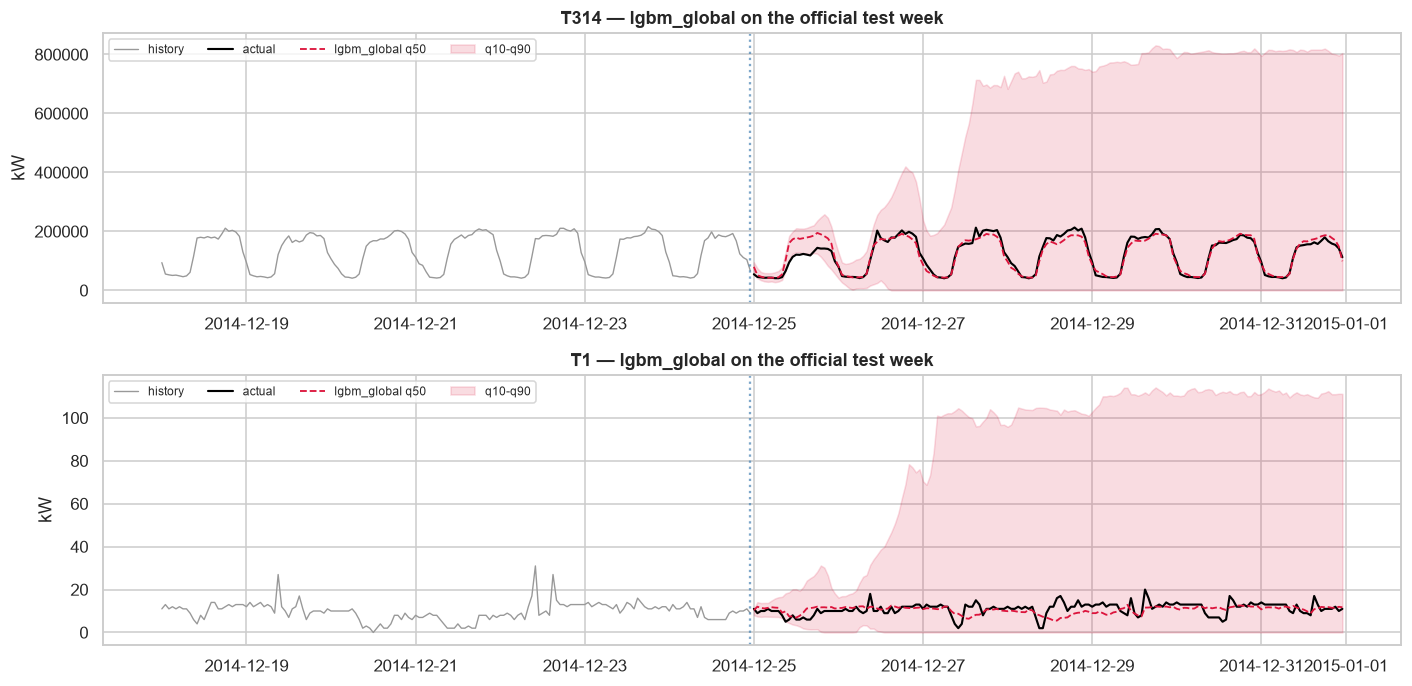

In [11]:
best = board.loc[~board["model"].str.startswith("seasonal_naive"), "model"].iloc[0]
w0 = windows.loc[windows["window"] == 0].iloc[0]
pos = int(w0["cutoff_pos"]); ctx = 168
fc_best = pd.read_parquet(FORECASTS / f"{best}.parquet")
fc_best = fc_best[fc_best["cutoff"] == w0["cutoff"]]
show_ids = [SERIES[wide.iloc[: pos + 1].mean().to_numpy().argmax()], "T1"]

fig, axes = plt.subplots(len(show_ids), 1, figsize=(13, 3.2 * len(show_ids)))
for ax, sid in zip(np.atleast_1d(axes), show_ids):
    hist = wide[sid].iloc[pos + 1 - ctx: pos + 1]
    actual = wide[sid].iloc[pos + 1: pos + 1 + HORIZON]
    g = fc_best[fc_best["unique_id"] == sid]
    ax.plot(hist.index, hist.values, color="0.6", lw=0.9, label="history")
    ax.plot(actual.index, actual.values, color="black", lw=1.4, label="actual")
    ax.plot(g["ds"].to_numpy(), g["q50"].to_numpy(), color="crimson", lw=1.2, ls="--", label=f"{best} q50")
    ax.fill_between(g["ds"].to_numpy(), g["q10"].to_numpy(), g["q90"].to_numpy(),
                    color="crimson", alpha=0.15, label="q10-q90")
    ax.axvline(w0["cutoff"], color="steelblue", ls=":", alpha=0.7)
    ax.set(title=f"{sid} — {best} on the official test week", ylabel="kW")
    ax.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "classical_best_forecast_examples.png", dpi=110); plt.show()

## 9. Summary

*(Filled in after the headless run — see the leaderboard above for the authoritative numbers.)*

**Takeaways**
- The classical baselines and the global LightGBM are all scored through the identical frozen harness,
  so they sit on one leaderboard with SeasonalNaive.
- The bar to beat is `SeasonalNaive(168)` at **MASE ≈ 1.11**; any model above it on MASE is, per
  ROADMAP principle #4, not yet pulling its weight.
- Probabilistic quality (WQL, coverage@80) is reported alongside the point metrics — the classical
  models' Gaussian PIs vs LightGBM's quantile-objective intervals.
- Each model's final full-history fit is serialized under `models/<name>/` (§7), so the Phase-8 serving
  layer can load a baseline with `StatsForecast.load` / `MLForecast.load` and forecast without refitting.

**Next → Phase 5 (PatchTST)** and **Phase 6 (Chronos)**, each pushed through this same harness.